In [2]:
import polars as pl
import seaborn as sns
import numpy as np
import pandas as pd
# mesmo não usando ela para gerar os graficos, as figuras
# podem ser alteradas por ela
import matplotlib.pyplot as plt

In [3]:
# desativar a notação cientifica
pl.Config.set_fmt_float('full')
# definir numero maximo de casa pos virgula
pl.Config.set_float_precision(2)

polars.config.Config

In [4]:
ARQUIVO = r'C:\Users\lucas.emoura\Documents\PastaLucas\aula01_UC2\aula02\dados_bronze\df_bf.parquet'

In [5]:
df_bf = pl.read_parquet(ARQUIVO)

In [6]:
df_bf.glimpse()

Rows: 61405684
Columns: 9
$ MÊS COMPETÊNCIA        <i64> 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501
$ MÊS REFERÊNCIA         <i64> 202308, 202309, 202310, 202311, 202312, 202401, 202401, 202401, 202401, 202401
$ UF                     <str> 'SP', 'SP', 'SP', 'SP', 'SP', 'CE', 'PA', 'SP', 'SP', 'SP'
$ CÓDIGO MUNICÍPIO SIAFI <i64> 7071, 7071, 7071, 7071, 7071, 1389, 479, 6313, 6313, 6887
$ NOME MUNICÍPIO         <str> 'SANTOS', 'SANTOS', 'SANTOS', 'SANTOS', 'SANTOS', 'FORTALEZA', 'LIMOEIRO DO AJURU', 'CARAPICUIBA', 'CARAPICUIBA', 'PIRASSUNUNGA'
$ CPF FAVORECIDO         <str> '***.085.106-**', '***.085.106-**', '***.085.106-**', '***.085.106-**', '***.085.106-**', '***.854.493-**', '***.868.792-**', '***.972.798-**', '***.696.858-**', '***.295.298-**'
$ NIS FAVORECIDO         <i64> 20643890445, 20643890445, 20643890445, 20643890445, 20643890445, 13024055192, 16025132403, 13310239852, 20217442743, 16017425650
$ NOME FAVORECIDO        <str> 'FERNANDA RAMO

In [7]:
df_por_uf = (
    df_bf.group_by('UF')
    .agg(pl.col('VALOR PARCELA').sum())
).sort(by= 'VALOR PARCELA', descending=True)
df_por_uf

UF,VALOR PARCELA
str,f64
"""BA""",4873812943.00
"""SP""",4832367370.00
"""PE""",3144489836.00
"""RJ""",3110091213.00
"""MG""",3066228734.00
…,…
"""TO""",318216159.00
"""AC""",283759378.00
"""RO""",269374412.00


In [8]:
df_por_uf_media = df_bf.group_by('UF').agg(
    pl.col('VALOR PARCELA').mean()
).sort(by='VALOR PARCELA', descending=True)
df_por_uf_media

UF,VALOR PARCELA
str,f64
"""RR""",735.05
"""AM""",725.02
"""AC""",716.49
"""AP""",715.44
"""PA""",695.76
…,…
"""BA""",658.33
"""PR""",657.92
"""SP""",657.81


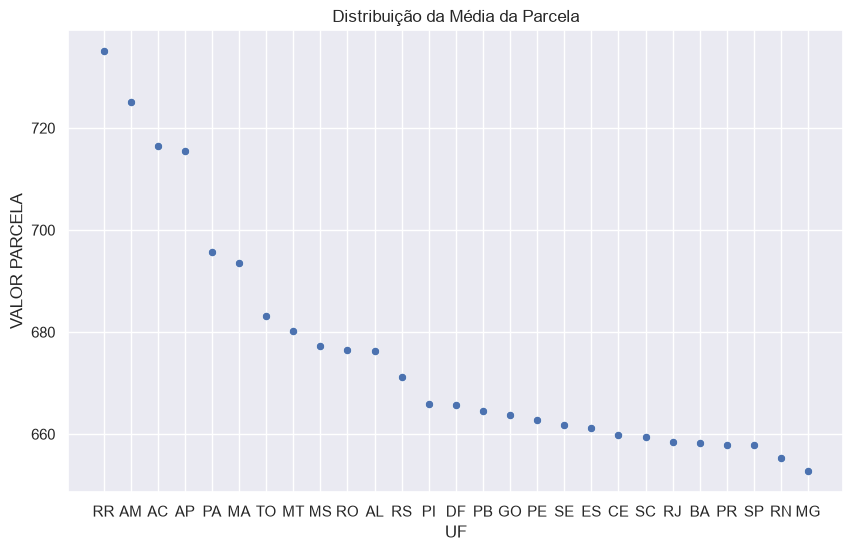

In [14]:
# plot com SNS
# MÊS COMPETÊNCIA

# mudar (configurar) tema do sns
sns.set_theme(style= 'darkgrid')
# area da figura
plt.figure(figsize=(10,6))
sns.scatterplot(df_por_uf_media,
             x='UF',
             y='VALOR PARCELA')
plt.title('Distribuição da Média da Parcela')
plt.show()

In [10]:
df_rj = df_bf.filter(pl.col('UF') == 'RJ')
df_rj.glimpse()

Rows: 4723193
Columns: 9
$ MÊS COMPETÊNCIA        <i64> 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501, 202501
$ MÊS REFERÊNCIA         <i64> 202406, 202407, 202407, 202407, 202407, 202407, 202407, 202407, 202407, 202407
$ UF                     <str> 'RJ', 'RJ', 'RJ', 'RJ', 'RJ', 'RJ', 'RJ', 'RJ', 'RJ', 'RJ'
$ CÓDIGO MUNICÍPIO SIAFI <i64> 5869, 5801, 5803, 5807, 5807, 5807, 2909, 5813, 5813, 5813
$ NOME MUNICÍPIO         <str> 'NOVA IGUACU', 'ANGRA DOS REIS', 'ARARUAMA', 'BARRA MANSA', 'BARRA MANSA', 'BARRA MANSA', 'BELFORD ROXO', 'CABO FRIO', 'CABO FRIO', 'CABO FRIO'
$ CPF FAVORECIDO         <str> '', '', '***.319.337-**', '', '***.924.687-**', '***.847.407-**', '***.533.967-**', '***.820.616-**', '***.279.557-**', ''
$ NIS FAVORECIDO         <i64> 17009152797, 13907790986, 16590291285, 21226891375, 13232334627, 20190198170, 10828947136, 16204145798, 16450735784, 12737735604
$ NOME FAVORECIDO        <str> 'PAULO DUARTE DOS SANTOS JUNIOR', 'CAMILA INACIO GOMES'